<a href="https://colab.research.google.com/github/ChristophWuersch/FeatureEngineering/blob/main/FeatureEngineering_TEMPLATE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="./mse_logo.png" width="340" align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br> 
<a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

# **Feature Engineering**




# Group 5 · Feature Selection II
## Part 1: Regularization as Feature Selection


---

## 🗺️ What This Section Is About

This section covers **Regularization as Feature Selection** — the idea that certain regularization techniques, when applied during model training, can automatically identify and discard irrelevant features.

### Context within Group 5

Our group covers four interconnected topics in Feature Selection II:

| Part | Topic | Core idea |
|---|---|---|
| 1 | **Regularization as Feature Selection** | How adding a penalty term to the loss function can shrink coefficients to exactly zero |
| 2 | Lasso Regression | Using Lasso specifically as a regression model: tuning, evaluation, interpretation |
| 3 | Model-Based Feature Selection | Using tree models (e.g. Random Forest) to rank features by importance |
| 4 | Recursive Feature Elimination (RFE) | Iteratively removing the weakest features based on model feedback |

### What makes this section different from Lasso Regression?

Both sections use Lasso — but the perspective differs:

- **Lasso Regression** (Part 2) asks: *How do I fit the best possible regression model with Lasso?* → focus on prediction quality, hyperparameter tuning, coefficient interpretation.
- **Regularization as Feature Selection** (this section) asks: *Why and how does regularization produce sparse models?* → focus on the mechanism, the geometry behind L1 vs. L2, and the resulting sparsity as a feature selection tool.

> 💡 Think of it this way: Part 2 treats Lasso as a *regression tool*. This section treats it as a *feature selector* — and explains *why* it works that way.

---

## 🧠 The Problem: Why Not Just Use All Features?

Imagine predicting apartment prices with 10 features:

- Area, number of rooms, location, year built... ✅ *genuinely relevant*
- Street number, wall colour... ❌ *noise — no real predictive value*

A standard linear model (OLS) minimises the training error and **uses all features**, including the irrelevant ones. It may learn something like:

```
Price = 500·Area + 300·Rooms + 9999·StreetNumber − 9850·WallColour + ...
```

The last two coefficients are huge and cancel each other out. The model has essentially **memorised the training data** — it will fail on new data. This is called **overfitting**.

---

## 🔧 The Solution: Add a Penalty for Complexity

Regularization adds a **penalty term** to the loss function that discourages large coefficients:

| Method | Loss function minimised |
|---|---|
| OLS (no regularization) | $\sum(y_i - \hat{y}_i)^2$ |
| **Ridge (L2)** | $\sum(y_i - \hat{y}_i)^2 + \alpha \sum w_i^2$      |
| **Lasso (L1)** | $\sum(y_i - \hat{y}_i)^2 + \alpha \sum \vert w_i \vert$      |
| **ElasticNet** | $\sum(y_i - \hat{y}_i)^2 + \alpha_1 \sum \vert w_i \vert + \alpha_2 \sum w_i^2$ |

The model can no longer minimise the error by making coefficients arbitrarily large — it must find a **compromise** between fitting the data well and keeping coefficients small.

**α controls this trade-off:**
- `α = 0` → no penalty → identical to OLS → overfitting possible
- `α = ∞` → maximum penalty → all coefficients = 0 → underfitting
- `α = optimal` → somewhere in between → good generalisation

---

## 🎯 What Has This Got to Do with Feature Selection?

Here is the key insight:

**Lasso (L1) can push coefficients to *exactly* zero.** When a coefficient becomes zero, the corresponding feature has no influence on the prediction — it has been implicitly removed from the model.

```
Price = 500·Area + 300·Rooms + 0·StreetNumber + 0·WallColour + ...
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                               These features are gone — Lasso eliminated them
```

This is **automatic feature selection during training** — no manual inspection needed.

| Regularization | Penalty shape | Can produce exact zeros? | Acts as feature selector? |
|---|---|---|---|
| **Ridge (L2)** | $\sum w_i^2$ | ❌ No — only shrinks | ❌ No |
| **Lasso (L1)** | $\sum \|w_i\|$ | ✅ Yes | ✅ Yes |
| **ElasticNet** | mix of both | ✅ Partially | ✅ Partially |

Why does L1 produce zeros but L2 does not? That is exactly what the geometry plot in Section 1 will show.

---
## Setup: Imports

Before anything else, we load all necessary libraries:

- **`numpy`** — numerical computing (arrays, math operations)
- **`pandas`** — tabular data (DataFrames)
- **`matplotlib`** — plotting
- **`sklearn`** — machine learning: datasets, models, preprocessing, evaluation
- **`np.random.seed(42)`** — fixes all randomness so results are reproducible every time you run the notebook

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

# Reproducibility: same random results every run
np.random.seed(42)

---
## 1. The Geometry Behind L1 vs. L2

### Why does Lasso produce zeros, but Ridge does not?

Both methods constrain how large the coefficients can be — but they use a **different shape** for that constraint region.

Think of it like this: the training loss is a landscape of hills and valleys. The unconstrained optimum (the star ★ in the plot) is the lowest point. Regularization forces the solution to stay within a certain region — like drawing a fence around the allowed area.

- **Ridge (L2):** the fence is a **smooth circle**. The loss contours (ellipses) can touch the circle almost anywhere on its smooth surface — almost never exactly on an axis. So $w_1$ or $w_2$ almost never becomes exactly zero.

- **Lasso (L1):** the fence is a **diamond**. It has sharp corners that lie exactly on the axes. The loss contours are much more likely to first touch the diamond at one of these corners — where one of the coefficients is exactly zero.

> 💡 **Analogy:** Imagine rolling a ball towards a fence. If the fence is a smooth circle, the ball stops somewhere on the curve. If the fence is a diamond with sharp corners, the ball very often gets caught in a corner — and at those corners, one coordinate is exactly zero.

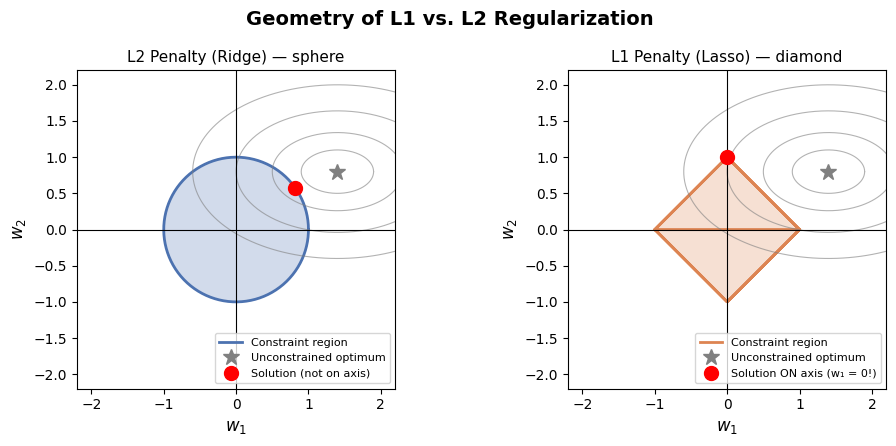

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Geometry of L1 vs. L2 Regularization', fontsize=14, fontweight='bold')

for ax, title, constraint_fn, color in zip(
    axes,
    ['L2 Penalty (Ridge) — sphere', 'L1 Penalty (Lasso) — diamond'],
    ['circle', 'diamond'],
    ['#4C72B0', '#DD8452']
):
    theta = np.linspace(0, 2 * np.pi, 300)

    # Draw the constraint region (circle for Ridge, diamond for Lasso)
    if constraint_fn == 'circle':
        cx, cy = np.cos(theta), np.sin(theta)
    else:
        t = np.linspace(-1, 1, 300)
        cx = np.concatenate([t, t[::-1], -t, -t[::-1]])
        cy = np.concatenate([1 - np.abs(t), -(1 - np.abs(t[::-1])), -(1 - np.abs(t)), (1 - np.abs(t[::-1]))])

    ax.fill(cx, cy, alpha=0.25, color=color)
    ax.plot(cx, cy, color=color, lw=2, label='Constraint region')

    # Draw loss contours (ellipses) centered at the unconstrained optimum
    opt_x, opt_y = 1.4, 0.8
    for r in [0.5, 0.9, 1.4, 2.0]:
        ex = opt_x + r * 1.0 * np.cos(theta)
        ey = opt_y + r * 0.6 * np.sin(theta)
        ax.plot(ex, ey, 'gray', lw=0.8, alpha=0.6)

    # Mark unconstrained optimum (where we would land without regularization)
    ax.plot(opt_x, opt_y, '*', color='gray', ms=12, label='Unconstrained optimum')

    # Mark where the loss contour first touches the constraint region (= regularized solution)
    if constraint_fn == 'circle':
        sol_x, sol_y = 0.82, 0.57
        label = 'Solution (not on axis)'
    else:
        sol_x, sol_y = 0.0, 1.0   # hits a corner → w1 = 0 exactly!
        label = 'Solution ON axis (w₁ = 0!)'

    ax.plot(sol_x, sol_y, 'o', color='red', ms=10, zorder=5, label=label)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.set_xlabel('$w_1$', fontsize=12)
    ax.set_ylabel('$w_2$', fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

**Reading the plot:**
- The **coloured region** = the constraint zone (coefficients must stay inside)
- The **grey ellipses** = contour lines of the loss function (like altitude lines on a map — smaller ellipse = lower loss = better fit)
- The **grey star ★** = where OLS would land without any constraint
- The **red dot** = the regularised solution (where the smallest ellipse first touches the constraint region)

Notice: for Ridge (left), the red dot sits somewhere on the smooth curve — both $w_1$ and $w_2$ are non-zero. For Lasso (right), the red dot lands exactly on the corner of the diamond where $w_1 = 0$. **That feature has been eliminated.**

---
## 2. Dataset: Diabetes

We use the **Diabetes dataset** — a classic benchmark from `sklearn`:
- **442 patients**, each described by **10 medical features** (age, sex, BMI, blood pressure, and 6 blood serum measurements)
- **Target:** a quantitative measure of disease progression one year after the baseline measurement

This is a regression problem: predict a continuous number (disease progression score) from 10 features. It is a good test case for regularization because some features are more predictive than others — Lasso should be able to identify and eliminate the weakest ones.

In [ ]:
# Load the dataset as a pandas DataFrame
data = load_diabetes(as_frame=True)
X, y = data.data, data.target

print(f"Shape: {X.shape}")             # (442 patients, 10 features)
print(f"Features: {list(X.columns)}")
print(f"Target range: [{y.min():.0f}, {y.max():.0f}]")
X.head(3)                              # preview first 3 rows

Shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target range: [25, 346]


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930


### Train/Test Split and Standardisation

Before training, two important preparation steps:

**1. Train/test split:**
We hold out 20% of the data as a test set. The model never sees this data during training — it is used only at the end to evaluate how well the model generalises to unseen patients.

**2. Standardisation (z-transform):**
Regularization penalises large coefficients. But if one feature is measured in kilometres and another in millimetres, their coefficients will naturally differ — not because one feature is more important, but just because of the units. Regularization would then unfairly penalise some features over others.

Standardisation brings all features to **mean = 0, standard deviation = 1**, making the penalty fair across all features.

> ⚠️ **Data leakage warning:** We fit the scaler only on the training data (`fit_transform`), then apply the same transformation to the test data (`transform`). If we fitted on the full dataset, we would be peeking at the test data during preprocessing — that would corrupt the evaluation.

In [ ]:
# Split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardise: fit on train only, then apply the same transform to test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # learns mean & std from training data
X_test_sc  = scaler.transform(X_test)        # applies the same transform — no refitting!

print("Train size:", X_train_sc.shape, "| Test size:", X_test_sc.shape)

Train size: (353, 10) | Test size: (89, 10)


---
## 3. Ridge vs. Lasso vs. ElasticNet — Coefficient Comparison

Now we train all three models with the same penalty strength (`alpha = 1.0`) and compare their coefficients.

**What to look for:**
- **Ridge:** all 10 coefficients are non-zero (just smaller than OLS would give)
- **Lasso:** some coefficients are exactly zero → those features are eliminated
- **ElasticNet:** a mix — usually fewer zeros than pure Lasso, but more sparsity than Ridge

We also compute **R²** (coefficient of determination) on the test set — a measure of prediction quality where 1.0 = perfect and 0.0 = no better than always predicting the mean.

In [ ]:
alpha = 1.0  # same penalty strength for all three models

models = {
    'Ridge (L2)':  Ridge(alpha=alpha),
    'Lasso (L1)':  Lasso(alpha=alpha),
    'ElasticNet':  ElasticNet(alpha=alpha, l1_ratio=0.5),  # 50% L1, 50% L2
}

feature_names = list(X.columns)
results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)           # train the model
    y_pred = model.predict(X_test_sc)        # predict on unseen test data
    results[name] = {
        'coef':       model.coef_,                   # one learned coefficient per feature
        'r2':         r2_score(y_test, y_pred),       # prediction quality on test set
        'n_selected': np.sum(model.coef_ != 0)        # how many features survived?
    }
    print(f"{name:20s} | R² = {results[name]['r2']:.3f} | Features kept: {results[name]['n_selected']}/{X.shape[1]}")

Ridge (L2)           | R² = 0.454 | Features kept: 10/10
Lasso (L1)           | R² = 0.467 | Features kept: 9/10
ElasticNet           | R² = 0.455 | Features kept: 10/10


The numbers already tell the story — Lasso keeps fewer features than Ridge but achieves similar R². Now let us visualise the individual coefficients to see *which* features were eliminated and by how much each was shrunk.

In [ ]:
# One bar chart per model, showing the value of each feature's coefficient
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.suptitle('Coefficients: Ridge vs. Lasso vs. ElasticNet  (α = 1.0)', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    coefs = res['coef']
    # Blue = positive contribution, orange = negative contribution
    bar_colors = ['#4C72B0' if c > 0 else '#DD8452' for c in coefs]
    bars = ax.barh(feature_names, coefs, color=bar_colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', lw=1)
    ax.set_title(f"{name}\nR²={res['r2']:.3f} | kept {res['n_selected']}/{len(coefs)}", fontsize=10)
    ax.set_xlabel('Coefficient value')

    # Grey out features that were eliminated (coefficient = 0)
    for bar, val in zip(bars, coefs):
        if val == 0:
            bar.set_alpha(0.2)
            ax.text(1, bar.get_y() + bar.get_height()/2,
                    ' zero', va='center', fontsize=7, color='gray')

axes[0].set_ylabel('Feature')
plt.tight_layout()
plt.show()

print("Features set to zero by Lasso:",
      [f for f, c in zip(feature_names, results['Lasso (L1)']['coef']) if c == 0])

### Part2: Lassoregression

LASSO is an acronym that stands for ‘least absolute shrinkage and selection operator’. It is a machine learning technique that performs both shrinkage and variable selection to simplify linear regression models and prevent overfitting.

$\min_{\beta}\left(\sum_{i=1}^{n}(y_i-\hat{y}i)^2 + \lambda\sum{j=1}^{p}|\beta_j|\right)$

$\lambda$ = regularization parameter

$\beta_{j}$ = feature coefficients

$𝑝$ = number of features


Advantages:
- Performs automatic feature selection
- Reduces overfitting
- Produces simpler interpretable models
- Works well when p > n (many features)

Limitations:
- If features are highly correlated, Lasso may randomly select one
- Can remove useful features if λ is too large
- Linear model → cannot capture complex nonlinear relationships

In [ ]:
from sklearn.linear_model import Lasso # Import the Lasso (Least Absolute Shrinkage and Selection Operator) regression model
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature scaling
from sklearn.pipeline import Pipeline # Import Pipeline to chain multiple processing steps
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import pandas as pd

diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test data
    random_state=42     # reproducibility
)

lasso = Pipeline([ # Create a scikit-learn pipeline for Lasso regression
    ('scaler', StandardScaler()), # Step 1: Scale features using StandardScaler
    ('model', Lasso(alpha=0.1)) # Step 2: Apply Lasso regression with a regularization strength (alpha) of 0.1
])

lasso.fit(X_train, y_train) # Train the Lasso regression model using the input features X and target variable y

coefficients = lasso.named_steps['model'].coef_ # Extract the coefficients from the trained Lasso model

selected_features = X.columns[coefficients != 0] # Select features where the corresponding Lasso coefficient is not zero (i.e., not eliminated)

print("Selected features:", selected_features) # Print the names of the features selected by Lasso regression

Selected features: Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')


In [ ]:
from sklearn.linear_model import LassoCV # Import LassoCV for Lasso regression with built-in cross-validation

lasso_cv = LassoCV(cv=5) # Create a LassoCV model with 5-fold cross-validation

lasso_cv.fit(X_train, y_tr) # Train the LassoCV model to find the optimal alpha using cross-validation

print("Best alpha:", lasso_cv.alpha_) # Print the best alpha (regularization strength) found by LassoCV

Best alpha: 0.003753767152691846


## Part 3: Model-basedfeatureselection(randomforest)

Accuracy (all features): 0.942
Top 5 features: [np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst concave points'), np.str_('worst radius'), np.str_('mean concave points')]
Accuracy (top 5 features): 0.912


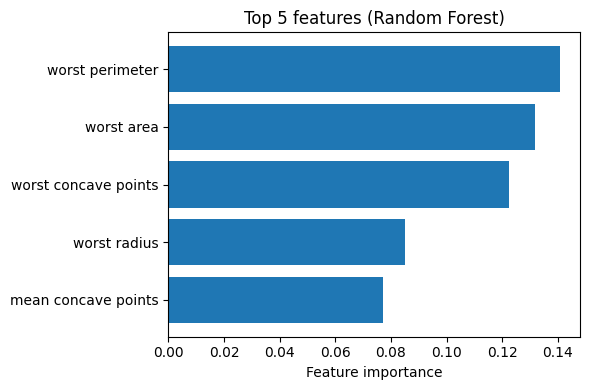

In [ ]:
#Model-based feature selection uses a model to estimate how importan each feature is for predicting the target.
#We then keep only the most important features and drop the rest.

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt


# 1) load data
data = load_breast_cancer()          # load breast cancer classification dataset
X = data.data                        # feature matrix (30 features)
y = data.target                      # target labels (benign / malignant)
feature_names = data.feature_names   # names of the 30 features

# split into train and test sets (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# 2) Train Random Forest with all features
rf_all = RandomForestClassifier(
    n_estimators=200,   # number of trees in the forest
    random_state=42,    # for reproducible results
    n_jobs=-1           # use all CPU cores
)
rf_all.fit(X_train, y_train)         # fit model on all features


y_pred_all = rf_all.predict(X_test)  # predictions on test set
acc_all = accuracy_score(y_test, y_pred_all)  # accuracy with all features
print("Accuracy (all features): {:.3f}".format(acc_all))


# 3) Compute feature importances
importances = rf_all.feature_importances_       # importance score for each feature
sorted_idx = np.argsort(importances)[::-1]      # indices sorted by importance (desc)


k = 5
top_idx = sorted_idx[:k]                        # indices of top k features
top_names = feature_names[top_idx]              # names of top k features
print("Top {} features:".format(k), list(top_names))


# 4) select the top k + Train a model only on the top k features
X_train_k = X_train[:, top_idx]                 # training data with only top k features
X_test_k = X_test[:, top_idx]                   # test data with only top k features


rf_k = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_k.fit(X_train_k, y_train)                    # fit model using only top k features


y_pred_k = rf_k.predict(X_test_k)               # predictions with reduced features
acc_k = accuracy_score(y_test, y_pred_k)        # accuracy with top k features
print("Accuracy (top {} features): {:.3f}".format(k, acc_k))


# 5) top k visualization
plt.figure(figsize=(6, 4))
# horizontal bar plot for the importance ofㄴ the top k features (reversed for nice order)
plt.barh(range(k), importances[top_idx][::-1])
plt.yticks(range(k), top_names[::-1])           # label bars with feature names
plt.xlabel("Feature importance")
plt.title("Top {} features (Random Forest)".format(k))
plt.tight_layout()
plt.show()


#We used a dataset with 30 features. We trained Random Forest with all 30 features and got 94% accuracy.
#Then we looked at the feature importance scores and selected only the top 5 features.
#We trained the model again with just these 5 features, and we got 91% accuracy.
#So, with only 5 features, we almost have the same performance. This means the other 25 features are not very useful.


## Part 4: RecursiveFeatureElimination(RFE)

### Description:
The goal of recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features.

### The idea:
RFE works by training a model on the initial set of features and then iteratively removing the least important features, or those with the smallest coefficients (for linear models), from the current set. This process is repeated on the remaining features until the desired number of features is reached. The features are ranked by their elimination order, with the last removed being the least important. This method helps to find a subset of features that contribute most to the model's performance.

In [ ]:
# Source: https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html

# Library needed:
from sklearn.feature_selection import RFE                               # Import RFE (Recursive Feature Elimination) for feature selection
from sklearn.linear_model import LinearRegression                       # Import LinearRegression as a potential estimator for RFE (though not used in the example below)

# Examples:

# Example from source:
from sklearn.datasets import make_friedman1                             # Import make_friedman1 to generate a synthetic dataset
from sklearn.feature_selection import RFE                               # Re-import RFE (already imported above, but good for self-contained example)
from sklearn.svm import SVR                                             # Import Support Vector Regressor (SVR) as the estimator for RFE
X, y = make_friedman1(n_samples=50, n_features=10, random_state=0)      # Generate a synthetic dataset with 50 samples and 10 features
estimator = SVR(kernel="linear")                                        # Initialize an SVR estimator with a linear kernel
selector = RFE(estimator, n_features_to_select=5, step=1)               # Create an RFE selector to select 5 features, removing 1 feature at each step
selector = selector.fit(X, y)                                           # Fit the RFE selector to the data to perform feature elimination
selector.support_                                                       # Display a boolean mask of selected features (True for selected, False for not selected)
# array([ True,  True,  True,  True,  True, False, False, False, False,
#        False])
selector.ranking_                                                       # Display the feature ranking, where 1 corresponds to selected features
# array([1, 1, 1, 1, 1, 6, 4, 3, 2, 5])

array([1, 1, 1, 1, 1, 6, 4, 3, 2, 5])

In [ ]:
# There are still errors in the code, thus it's non functional at the moment
# The idea is to classify the images provided as either a woman or an animal

import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
import cv2 as cv
from sklearn.model_selection import train_test_split
import numpy as np

imgNames = ["20251023_124459.jpg", "20251023_124808.jpg", "20251023_124937.jpg", "20251023_125050.jpg", "20251023_125109.jpg", "20251023_125121.jpg", "20251023_125142.jpg", "20251023_125207.jpg", "20251023_125239.jpg"]
img = np.array([None]*len(imgNames))
for ind,name in enumerate(imgNames):
    img[ind] = cv.imread(f"C:\\Users\Pascal\\Documents\\MSE_EE\\2_Semester\\FTP_MachLe_B\\W4\\FeatureEngineering\\images\\{name}")
classification = ["woman", "woman","woman", "animal", "animal", "animal", "animal", "animal", "animal"]

rfe = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("rfe", RFE(estimator=LogisticRegression(), n_features_to_select=1, step=1)),
    ]
)

x_train, x_test, y_train, y_test = train_test_split(img, classification, test_size=0.2, random_state=1)

rfe.fit(x_train, y_train)
y_preditct = rfe.predict(x_test)

print("Predicted Class\tActual Class")
for pre, act in zip(y_preditct, y_test):
    print(f"{pre}\t{act}")